In [1]:
# ASSIGNMENT NUMBER 1 BY MILIND KASHYAP (E22CSEU1317) BENNETT UNIVERSITY

In [7]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [8]:
# Step 2: Load dataset
df = pd.read_csv("/content/Sample_Data.csv")

if 'Values' in df.columns:
    df.rename(columns={'Values':'Voltage'}, inplace=True)

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.head()


/tmp/ipython-input-1388529445.py:9: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


,Voltage,Timestamp
0,100,2024-06-26 06:17:00
1,100,2024-06-26 06:18:00
2,100,2024-06-26 06:18:00
3,100,2024-06-26 06:18:00
4,100,2024-06-26 06:19:00


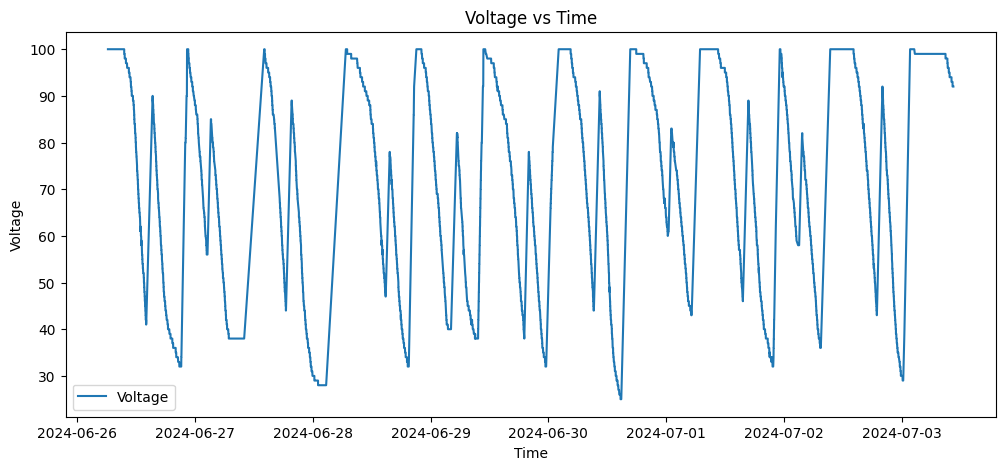

In [9]:
# Step 3: Plot Voltage over time
plt.figure(figsize=(12,5))
plt.plot(df['Timestamp'], df['Voltage'], label="Voltage")
plt.title("Voltage vs Time")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.show()


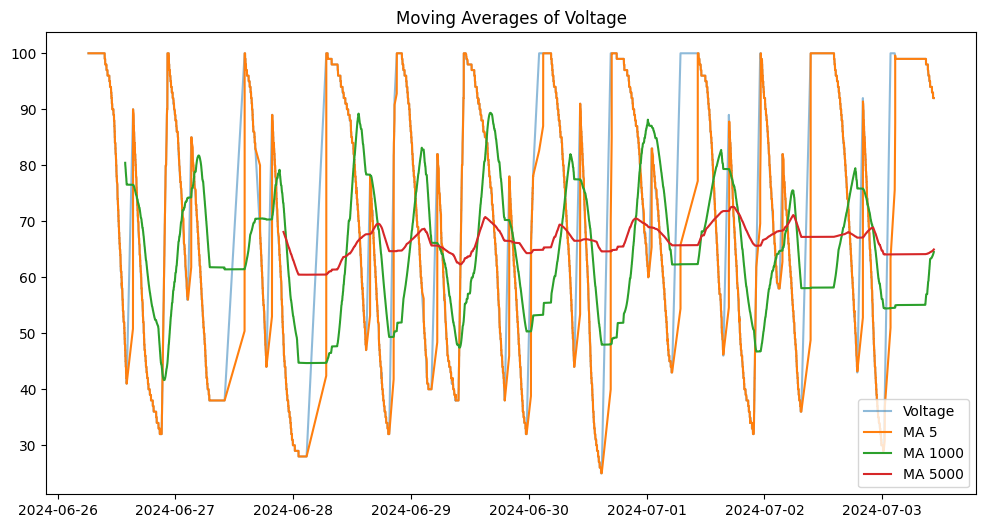

In [18]:
# Step 4: Moving averages
df['MA_5'] = df['Voltage'].rolling(5).mean()
df['MA_1000'] = df['Voltage'].rolling(1000).mean()
df['MA_5000'] = df['Voltage'].rolling(5000).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Timestamp'], df['Voltage'], alpha=0.5, label="Voltage")
plt.plot(df['Timestamp'], df['MA_5'], label="MA 5")
plt.plot(df['Timestamp'], df['MA_1000'], label="MA 1000")
plt.plot(df['Timestamp'], df['MA_5000'], label="MA 5000")
plt.title("Moving Averages of Voltage")
plt.legend()
plt.show()


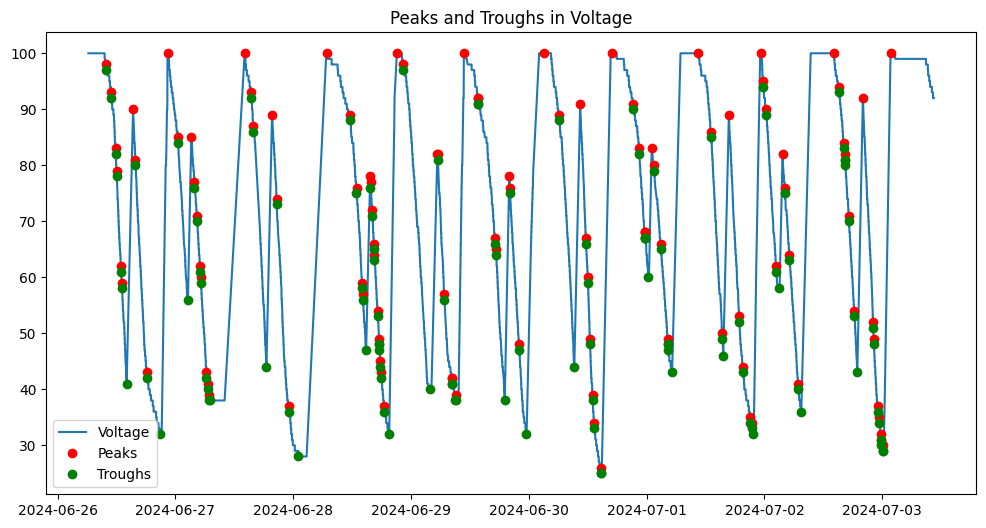

In [11]:
# Step 5: Peaks (high points) and Troughs (low points)
peaks, _ = find_peaks(df['Voltage'])
troughs, _ = find_peaks(-df['Voltage'])

plt.figure(figsize=(12,6))
plt.plot(df['Timestamp'], df['Voltage'], label="Voltage")
plt.plot(df['Timestamp'].iloc[peaks], df['Voltage'].iloc[peaks], "ro", label="Peaks")
plt.plot(df['Timestamp'].iloc[troughs], df['Voltage'].iloc[troughs], "go", label="Troughs")
plt.title("Peaks and Troughs in Voltage")
plt.legend()
plt.show()

peaks_list = df.iloc[peaks][['Timestamp','Voltage']]
troughs_list = df.iloc[troughs][['Timestamp','Voltage']]


In [12]:
# Step 6: Times when Voltage < 20
below_20 = df[df['Voltage'] < 20][['Timestamp','Voltage']]
below_20


,Timestamp,Voltage


In [19]:
df['Voltage'].min()


25

In [13]:
# Step 7: Detect accelerating downward slopes
df['d1'] = np.gradient(df['Voltage'])
df['d2'] = np.gradient(df['d1'])

accel_down = df[(df['d1'] < 0) & (df['d2'] < 0)][['Timestamp','Voltage']]
accel_down.head()


,Timestamp,Voltage
35,2024-06-26 09:36:00,100
59,2024-06-26 09:42:00,99
124,2024-06-26 09:58:00,98
173,2024-06-26 10:10:00,97
260,2024-06-26 10:33:00,96


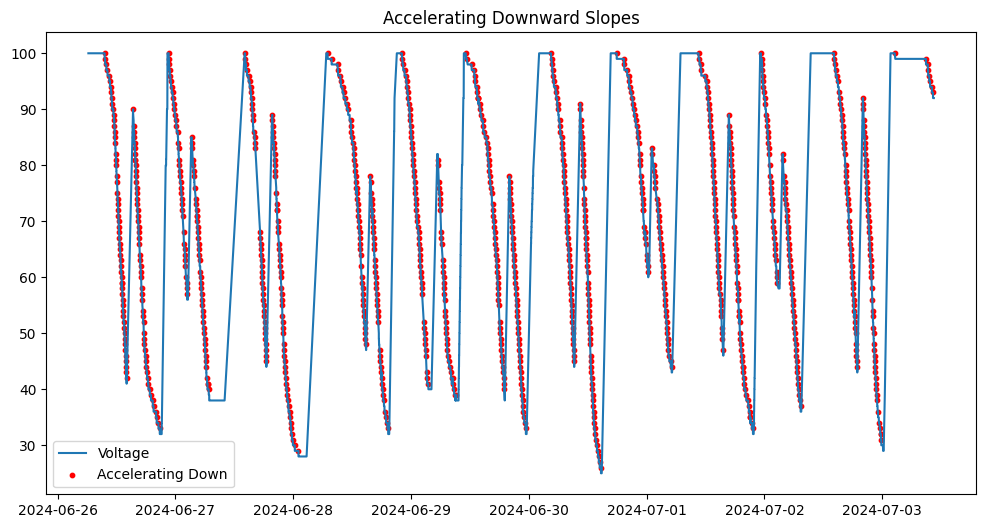

In [14]:
# Step 8: Plot with accelerating downward points
plt.figure(figsize=(12,6))
plt.plot(df['Timestamp'], df['Voltage'], label="Voltage")
plt.scatter(accel_down['Timestamp'], accel_down['Voltage'], color='red', s=10, label="Accelerating Down")
plt.title("Accelerating Downward Slopes")
plt.legend()
plt.show()


In [15]:
# Step 9: Final Outputs
print("🔹 Peaks:")
display(peaks_list.head())

print("🔹 Troughs:")
display(troughs_list.head())

print("🔹 Voltage < 20:")
display(below_20.head())

print("🔹 Accelerating Downward Slopes:")
display(accel_down.head())


🔹 Peaks:


,Timestamp,Voltage
122,2024-06-26 09:57:00,98
361,2024-06-26 10:58:00,93
557,2024-06-26 11:49:00,83
603,2024-06-26 12:01:00,79
798,2024-06-26 12:55:00,62


🔹 Troughs:


,Timestamp,Voltage
120,2024-06-26 09:57:00,97
360,2024-06-26 10:58:00,92
556,2024-06-26 11:49:00,82
602,2024-06-26 12:01:00,78
795,2024-06-26 12:55:00,61


🔹 Voltage < 20:


,Timestamp,Voltage


🔹 Accelerating Downward Slopes:


,Timestamp,Voltage
35,2024-06-26 09:36:00,100
59,2024-06-26 09:42:00,99
124,2024-06-26 09:58:00,98
173,2024-06-26 10:10:00,97
260,2024-06-26 10:33:00,96
